# Fiddler on the Proof — May 16, 2026

**Source:** [Can You Play Hide-and-Seek?](https://thefiddler.substack.com/p/can-you-play-hide-and-seek) — *The Fiddler on the Proof*, Substack

## Problem

I am playing hide-and-seek with my nephew. I start at point O, whereas my nephew can hide at point A, B or C. I can walk from O to A in 2 minutes, from O to B in 3 minutes, from O to C in 4 minutes, and from B to C in 5 minutes. To get from A to B or from A to C, I must pass through O. My goal is to minimize the time it takes to find him, no matter how clever his strategy might be. What is this optimal time?

## Extra Credit

My nephew can no longer hide at C, and is instead limited to A and B. But this time, he has a teleporter that can instantaneously transport him from A to B or from B to A. He can use the teleporter as many times as he wants. However, he can't react to my approach, and must instead plan out his transport schedule ahead of time. That said, he *does* know the precise time when the game starts. My goal is to minimize the *average* time it takes to find him, no matter how clever his strategy might be. What is this optimal time?

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import permutations

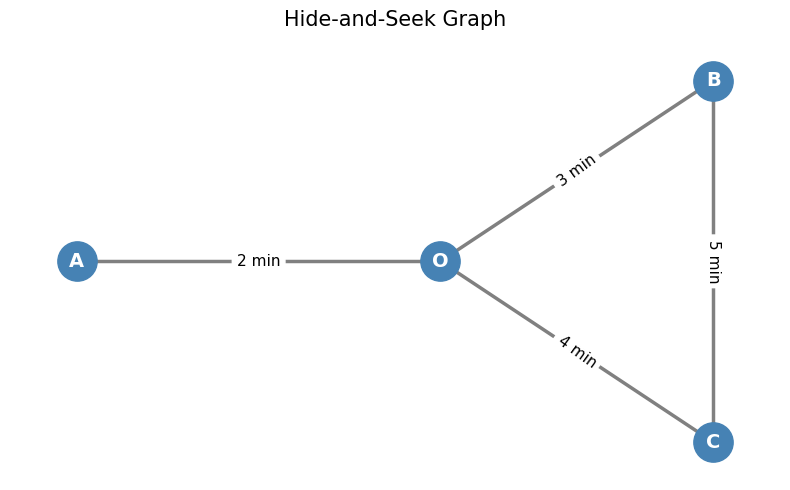

In [13]:
G = nx.Graph()
G.add_edge('O', 'A', weight=2)
G.add_edge('O', 'B', weight=3)
G.add_edge('O', 'C', weight=4)
G.add_edge('B', 'C', weight=5)

pos = {'O': (0, 0), 'A': (-2, 0), 'B': (1.5, 1), 'C': (1.5, -1)}

fig, ax = plt.subplots(figsize=(8, 5))
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='steelblue', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=14, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=2.5, edge_color='gray', ax=ax)
edge_labels = {(u, v): f"{d['weight']} min" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, ax=ax)
ax.set_title('Hide-and-Seek Graph', fontsize=15, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

shortest = dict(nx.all_pairs_dijkstra_path_length(G))
hiding_spots = ['A', 'B', 'C']
results = []

for route in permutations(hiding_spots):
    stops = ['O'] + list(route)
    cum_time = 0
    discovery = {}
    for i in range(1, len(stops)):
        cum_time += shortest[stops[i - 1]][stops[i]]
        discovery[stops[i]] = cum_time
    worst_case = max(discovery.values())
    avg_time = sum(discovery.values()) / len(hiding_spots)
    results.append({'route': ' → '.join(stops), 'discovery': discovery,
                    'worst_case': worst_case, 'avg_time': avg_time})

results.sort(key=lambda x: x['worst_case'])

df = pd.DataFrame([
    {'Route': r['route'],
     'If at A': r['discovery']['A'],
     'If at B': r['discovery']['B'],
     'If at C': r['discovery']['C'],
     'Avg (uniform)': r['avg_time']}
    for r in results
])

def highlight_best(row):
    style = 'background-color: #d4edda; font-weight: bold'
    return [style] * len(row) if row.name == 0 else [''] * len(row)

(df.style
   .apply(highlight_best, axis=1)
   .format({'Avg (uniform)': '{:.1f}'})
   .set_caption('Discovery times (minutes) by route and hiding spot — green = optimal')
   .set_table_styles([
       {'selector': 'caption',
        'props': [('font-size', '13px'), ('font-style', 'italic'), ('padding-bottom', '8px')]},
       {'selector': 'th',
        'props': [('text-align', 'center'), ('padding', '6px 16px'),
                  ('border-bottom', '2px solid #999')]},
       {'selector': 'td',
        'props': [('text-align', 'center'), ('padding', '5px 16px')]},
       {'selector': 'td:first-child',
        'props': [('text-align', 'left')]},
   ])
   .hide(axis='index'))

Route,If at A,If at B,If at C,Avg (uniform)
O → A → B → C,2,7,12,7.0
O → A → C → B,2,13,8,7.7
O → B → A → C,8,3,14,8.3
O → B → C → A,14,3,8,8.3
O → C → B → A,14,9,4,9.0
O → C → A → B,10,15,4,9.7


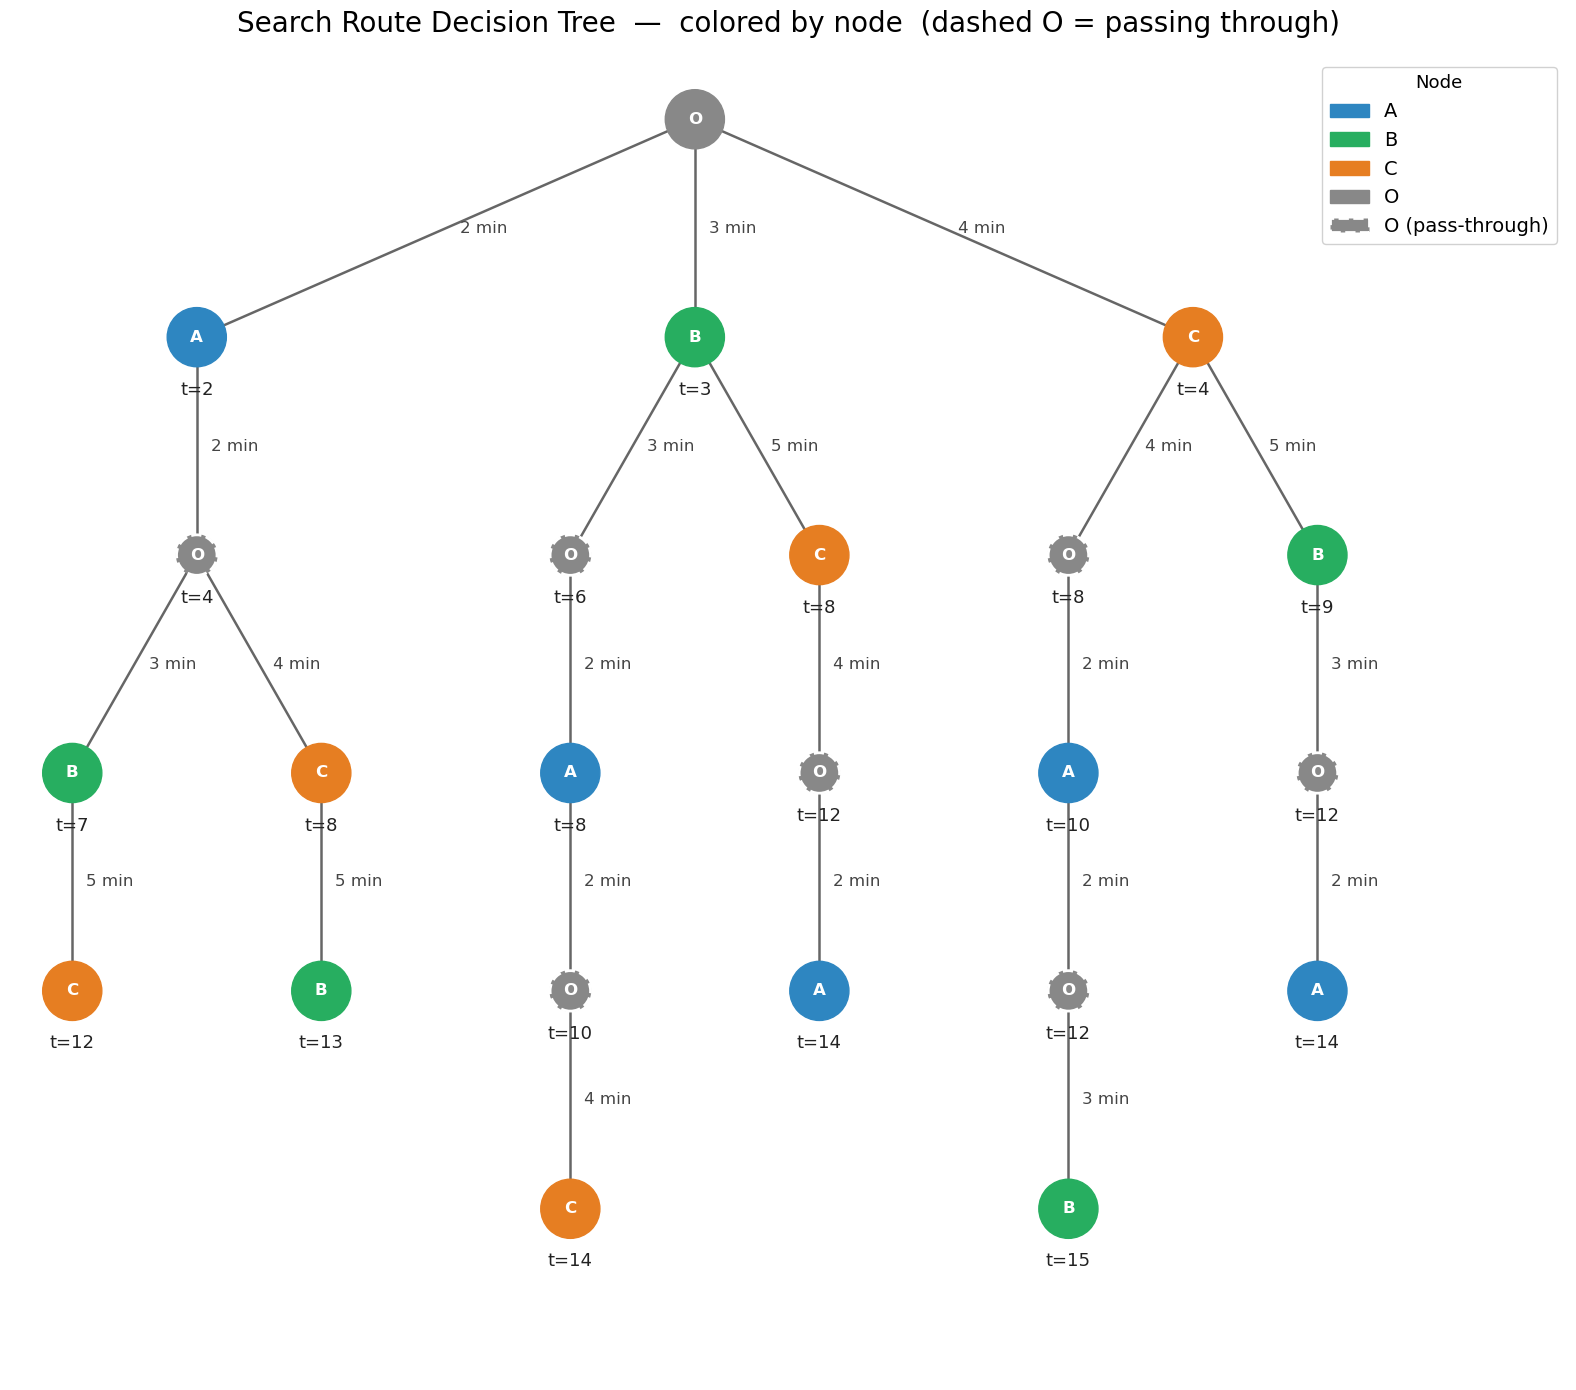

In [15]:
import matplotlib.patches as mpatches

# ── node colors ───────────────────────────────────────────────────────────────
NODE_COLOR = {'O': '#888888', 'A': '#2E86C1', 'B': '#27AE60', 'C': '#E67E22'}

# ── tree definition ───────────────────────────────────────────────────────────
# pass_thru=True marks intermediate O nodes (searcher returning to O en route)
def N(label, cum, w, children=None, pass_thru=False):
    return dict(label=label, cum=cum, w=w, pass_thru=pass_thru, children=children or [])

tree = N('O', 0, 0, [
    N('A', 2, 2, [
        N('O', 4, 2, pass_thru=True, children=[
            N('B', 7, 3, [N('C', 12, 5)]),
            N('C', 8, 4, [N('B', 13, 5)]),
        ])
    ]),
    N('B', 3, 3, [
        N('O', 6, 3, pass_thru=True, children=[
            N('A', 8, 2, [
                N('O', 10, 2, pass_thru=True, children=[N('C', 14, 4)])
            ])
        ]),
        N('C', 8, 5, [
            N('O', 12, 4, pass_thru=True, children=[N('A', 14, 2)])
        ]),
    ]),
    N('C', 4, 4, [
        N('O', 8, 4, pass_thru=True, children=[
            N('A', 10, 2, [
                N('O', 12, 2, pass_thru=True, children=[N('B', 15, 3)])
            ])
        ]),
        N('B', 9, 5, [
            N('O', 12, 3, pass_thru=True, children=[N('A', 14, 2)])
        ]),
    ]),
])

# ── layout: leaves get sequential x; internals get midpoint of first/last child ─
_leaf = [0]

def lay_out(node, depth=0):
    node['depth'] = depth
    if not node['children']:
        node['x'] = _leaf[0]
        _leaf[0] += 1
    else:
        for c in node['children']:
            lay_out(c, depth + 1)
        node['x'] = (node['children'][0]['x'] + node['children'][-1]['x']) / 2

lay_out(tree)

MAX_DEPTH = 5
ROW_H     = 2.8
XS        = 3.2   # horizontal scale
R, RP     = 0.38, 0.26   # normal vs pass-through radius

# ── draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 14))

def draw(node):
    x1 = node['x'] * XS
    y1 = (MAX_DEPTH - node['depth']) * ROW_H
    r1 = RP if node['pass_thru'] else R

    for child in node['children']:
        x2 = child['x'] * XS
        y2 = (MAX_DEPTH - child['depth']) * ROW_H
        r2 = RP if child['pass_thru'] else R
        dx, dy = x2 - x1, y2 - y1
        dist = (dx**2 + dy**2) ** 0.5
        ax.plot([x1 + r1*dx/dist, x2 - r2*dx/dist],
                [y1 + r1*dy/dist, y2 - r2*dy/dist],
                color='#666', lw=1.8, zorder=1)
        ax.text((x1 + x2) / 2 + 0.18, (y1 + y2) / 2,
                f'{child["w"]} min', ha='left', va='center', fontsize=12, color='#444')
        draw(child)

    ax.add_patch(plt.Circle((x1, y1), r1, color=NODE_COLOR[node['label']], zorder=3))
    if node['pass_thru']:
        ax.add_patch(plt.Circle((x1, y1), r1, fill=False,
                                edgecolor='white', lw=2, linestyle='--', zorder=4))
    ax.text(x1, y1, node['label'], ha='center', va='center',
            fontsize=12, fontweight='bold', color='white', zorder=5)
    if node['depth'] > 0:
        ax.text(x1, y1 - r1 - 0.18, f't={node["cum"]}',
                ha='center', va='top', fontsize=13, color='#222')

draw(tree)

legend_handles = [
    mpatches.Patch(color='#2E86C1', label='A'),
    mpatches.Patch(color='#27AE60', label='B'),
    mpatches.Patch(color='#E67E22', label='C'),
    mpatches.Patch(color='#888888', label='O'),
    mpatches.Patch(facecolor='#888888', edgecolor='white',
                   linestyle='--', linewidth=2, label='O (pass-through)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=14,
          framealpha=0.9, title='Node', title_fontsize=13)

ax.set_xlim(-0.8, _leaf[0] * XS)
ax.set_ylim(-2.2, MAX_DEPTH * ROW_H + 0.8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    'Search Route Decision Tree  —  colored by node  (dashed O = passing through)',
    fontsize=20, pad=18
)
plt.tight_layout()
plt.show()


In [20]:
for r in results:
    d = r['discovery']
    r['weighted_avg'] = 0.5 * d['A'] + 0.25 * d['B'] + 0.25 * d['C']

df_weighted = pd.DataFrame([
    {'Route': r['route'],
     'If at A': r['discovery']['A'],
     'If at B': r['discovery']['B'],
     'If at C': r['discovery']['C'],
     'Avg (A=50%, B=C=25%)': r['weighted_avg']}
    for r in sorted(results, key=lambda x: x['weighted_avg'])
])

(df_weighted.style
   .apply(highlight_best, axis=1)
   .format({'Avg (A=50%, B=C=25%)': '{:.2f}'})
   .set_caption('Discovery times (minutes) — A=50%, B=C=25% — green = optimal')
   .set_table_styles([
       {'selector': 'caption',
        'props': [('font-size', '13px'), ('font-style', 'italic'), ('padding-bottom', '8px')]},
       {'selector': 'th',
        'props': [('text-align', 'center'), ('padding', '6px 16px'),
                  ('border-bottom', '2px solid #999')]},
       {'selector': 'td',
        'props': [('text-align', 'center'), ('padding', '5px 16px')]},
       {'selector': 'td:first-child',
        'props': [('text-align', 'left')]},
   ])
   .hide(axis='index'))

Route,If at A,If at B,If at C,"Avg (A=50%, B=C=25%)"
O → A → B → C,2,7,12,5.75
O → A → C → B,2,13,8,6.25
O → B → A → C,8,3,14,8.25
O → B → C → A,14,3,8,9.75
O → C → A → B,10,15,4,9.75
O → C → B → A,14,9,4,10.25


In [27]:
import base64, io

# ── Capture graph figure as base64 PNG ───────────────────────────────────────
fig_graph, ax_graph = plt.subplots(figsize=(8, 5))
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='steelblue', ax=ax_graph)
nx.draw_networkx_labels(G, pos, font_size=14, font_color='white', font_weight='bold', ax=ax_graph)
nx.draw_networkx_edges(G, pos, width=2.5, edge_color='gray', ax=ax_graph)
edge_labels = {(u, v): f"{d['weight']} min" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, ax=ax_graph)
ax_graph.set_title('Hide-and-Seek Graph', fontsize=15, pad=12)
ax_graph.axis('off')
plt.tight_layout()

buf_graph = io.BytesIO()
fig_graph.savefig(buf_graph, format='png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig_graph)
buf_graph.seek(0)
graph_b64 = base64.b64encode(buf_graph.read()).decode()

# ── Capture tree figure as base64 PNG ────────────────────────────────────────
fig_out, ax = plt.subplots(figsize=(20, 14))
draw(tree)

ax.legend(handles=[
    mpatches.Patch(color='#2E86C1', label='A'),
    mpatches.Patch(color='#27AE60', label='B'),
    mpatches.Patch(color='#E67E22', label='C'),
    mpatches.Patch(color='#888888', label='O'),
    mpatches.Patch(facecolor='#888888', edgecolor='white',
                   linestyle='--', linewidth=2, label='O (pass-through)'),
], loc='upper right', fontsize=14, framealpha=0.9, title='Node', title_fontsize=13)
ax.set_xlim(-0.8, _leaf[0] * XS)
ax.set_ylim(-2.2, MAX_DEPTH * ROW_H + 0.8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    'Search Route Decision Tree  —  colored by node  (dashed O = passing through)',
    fontsize=20, pad=18
)
plt.tight_layout()

buf_tree = io.BytesIO()
fig_out.savefig(buf_tree, format='png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig_out)
buf_tree.seek(0)
tree_b64 = base64.b64encode(buf_tree.read()).decode()

# ── Uniform table HTML ────────────────────────────────────────────────────────
table_uniform_html = (df.style
    .apply(highlight_best, axis=1)
    .format({'Avg (uniform)': '{:.1f}'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'), ('padding', '8px 20px'),
            ('border-bottom', '2px solid #999'), ('background-color', '#f5f5f5'),
        ]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 20px')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
    ])
    .hide(axis='index')
    .to_html())

# ── Weighted table (A=50%, B=25%, C=25%) ─────────────────────────────────────
for r in results:
    d = r['discovery']
    r['weighted_avg'] = 0.5 * d['A'] + 0.25 * d['B'] + 0.25 * d['C']

results_weighted = sorted(results, key=lambda x: x['weighted_avg'])

df_weighted = pd.DataFrame([
    {'Route': r['route'],
     'If at A': r['discovery']['A'],
     'If at B': r['discovery']['B'],
     'If at C': r['discovery']['C'],
     'Avg (A=50%, B=C=25%)': r['weighted_avg']}
    for r in results_weighted
])

table_weighted_html = (df_weighted.style
    .apply(highlight_best, axis=1)
    .format({'Avg (A=50%, B=C=25%)': '{:.2f}'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'), ('padding', '8px 20px'),
            ('border-bottom', '2px solid #999'), ('background-color', '#f5f5f5'),
        ]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 20px')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
    ])
    .hide(axis='index')
    .to_html())

# ── Assemble HTML ─────────────────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Can You Play Hide-and-Seek? — Fiddler on the Proof</title>
  <style>
    body {{
      font-family: Georgia, serif;
      max-width: 960px;
      margin: 40px auto;
      padding: 0 24px;
      color: #222;
      line-height: 1.7;
    }}
    h1 {{ font-size: 1.8rem; margin-bottom: 4px; }}
    .source {{ font-size: 0.9rem; color: #666; margin-bottom: 32px; }}
    h2 {{ font-size: 1.2rem; border-bottom: 1px solid #ddd; padding-bottom: 6px; margin-top: 36px; }}
    .problem {{
      background: #f9f9f9;
      border-left: 4px solid #aaa;
      padding: 16px 20px;
      margin: 20px 0;
      font-style: italic;
    }}
    .answer {{
      background: #eaf6ed;
      border-left: 4px solid #27ae60;
      padding: 16px 20px;
      margin: 28px 0;
    }}
    figure {{ margin: 32px 0; text-align: center; }}
    figure img {{ max-width: 100%; border: 1px solid #e0e0e0; border-radius: 4px; }}
    figcaption {{ font-size: 0.88rem; color: #666; margin-top: 8px; font-style: italic; }}
    .table-wrap {{ overflow-x: auto; margin: 24px 0; }}
  </style>
</head>
<body>

<h1>Can You Play Hide-and-Seek?</h1>
<p class="source">
  <a href="https://thefiddler.substack.com/p/can-you-play-hide-and-seek">Fiddler on the Proof</a>
  &mdash; May 16, 2026
</p>

<h2>The Problem</h2>
<div class="problem">
  <p>I am playing hide-and-seek with my nephew. I start at point O, whereas my nephew can hide at
  point A, B or C. I can walk from O to A in 2&nbsp;minutes, from O to B in 3&nbsp;minutes, from
  O to C in 4&nbsp;minutes, and from B to C in 5&nbsp;minutes. To get from A to B or from A to C,
  I must pass through O. My goal is to minimize the time it takes to find him, no matter how clever
  his strategy might be. What is this optimal time?</p>
</div>

<h2>Answer</h2>
<div class="answer">
  <p>Since we&#8217;re optimizing for time regardless of the nephew&#8217;s strategy, we have to
  assume they&#8217;ll hide at A, B or C with uniform probability, which is to say 1/3rd of the
  time. The table below compares the 6 paths, showing that the optimal route is O-&gt;A-&gt;B-&gt;C
  for an average of 7 minutes.</p>
  <p>Just for fun: we can adjust the probabilities of the nephew hiding in each location according to
  binary decision to better model how a hiding spot is chosen. In this case, the nephew would hide at A 50% of the time and each of B and C 25% of the time. 
  The previous route is still optimal since it travels to A first, and A carries more weight as a hiding spot. This averages 5.75 minutes instead of 7 minutes.</p>
</div>

<h2>The Graph</h2>
<figure>
  <img src="data:image/png;base64,{graph_b64}" alt="Hide-and-seek graph">
  <figcaption>Travel times between locations. A has no direct connection to B or C &mdash;
  all such trips must pass through O.</figcaption>
</figure>

<h2>Decision Tree</h2>
<figure>
  <img src="data:image/png;base64,{tree_b64}" alt="Search route decision tree">
  <figcaption>All six possible search routes. Dashed O nodes appear when traveling between A and
  another node, since those paths must pass through O. Nodes are colored by destination.</figcaption>
</figure>

<h2>All Routes — Uniform Distribution (A = B = C = 33%)</h2>
<div class="table-wrap">
  {table_uniform_html}
</div>

<h2>All Routes — Weighted Distribution (A = 50%, B = C = 25%)</h2>
<div class="table-wrap">
  {table_weighted_html}
</div>

</body>
</html>"""

with open('fiddler_solution_20260515.html', 'w') as f:
    f.write(html)

print("Written: fiddler_solution_20260515.html")


Written: fiddler_solution_20260515.html
